# 14-Telemetry Scraping & Observability Metrology (Prometheus)

In Lesson 13, we maximized serving throughput by replacing the Python GIL with dynamic continuous batching engines like vLLM and Triton. Our API can now process 10,000 requests per second.

However, operating a high-throughput system without **Observability** is like flying a supersonic jet at midnight with the dashboard turned off. If a specific model weight gets corrupted, or if a memory leak causes API latency to drift from 50 milliseconds to 5 seconds, standard text logs (like those parsed in Lesson 05) will not save you. Parsing text logs takes too much time to prevent an active system outage.

To engineer Enterprise Reliability, we implement **Prometheus**, an open-source, time-series metrology engine. Prometheus does not wait for applications to send it logs. Instead, it systematically actively "scrapes" mathematical endpoints across the entire infrastructure grid, compiling high-definition matrices of system health, error rates, and latency distributions.

# 1. The Mathematics of Time-Series Metrology & Latency

### The Time-Series Vector ($M$)

In Prometheus, a metric is not a text string; it is a strict mathematical time-series vector defined by a metric name, a set of key-value label dimensions, a timestamp $t$, and a 64-bit float payload $y$:


$$M = \langle \text{Name}, \{L_1, L_2, \dots, L_n\}, t, y \rangle$$

By tagging vectors with labels (e.g., `model_version="v1"`, `gpu_id="0"`), we construct a multi-dimensional matrix. We can mathematically slice this matrix using PromQL (Prometheus Query Language) to isolate variables.

### The Mathematics of Rate ($\frac{d}{dt}$)

Counters in Prometheus are monotonically increasing (they only go up, like an odometer). To calculate the actual Requests Per Second (RPS) $\lambda$, Prometheus computes the discrete derivative over a temporal window $\Delta t$:


$$\text{rate}(x[t]) = \frac{x_t - x_{t-\Delta t}}{\Delta t}$$


If a container crashes and restarts, its counter resets to 0. The `rate()` function mathematically detects this drop and compensates automatically, preventing false negative RPS alerts.

### The Service Level Agreement (P99 Latency)

In MLOps, looking at the "Average" (Mean) latency is dangerous. If 99 users get a 10ms response, but 1 user waits 5,000ms, the mean is $\approx 60$ms, which looks perfectly healthy. Meanwhile, a paying customer just experienced a 5-second timeout.

We measure performance strictly using **Quantiles**, specifically the 99th Percentile ($P_{99}$). The $P_{99}$ latency defines the temporal threshold $x$ such that exactly 99% of requests are faster than $x$:


$$P(X \le x) = 0.99$$


Prometheus calculates this using Histograms—grouping request latencies into discrete mathematical "buckets" and using linear interpolation to estimate the $P_{99}$ boundary in real time.

# 2. Imperative Execution: Instrumenting the Metric Endpoint

We cannot scrape metrics if the application doesn't expose them. We will use Python's `prometheus_client` to inject an active metrology registry directly into a simulated API engine.

In [1]:
import os
import time

print("--- 🚀 Initializing Prometheus Metrology Lab ---")

obs_sandbox = "./observability_sandbox"
os.makedirs(obs_sandbox, exist_ok=True)

# 1. 📝 Instrument the Python Application (app_metrics.py)
python_metrics_code = """
from prometheus_client import start_http_server, Counter, Histogram
import time
import random

# 1. Define the Metric Schemas
# Counters only go up (Total Requests)
REQUEST_COUNT = Counter(
    'inference_requests_total', 
    'Total number of inference requests', 
    ['model_version']
)

# Histograms track distributions (Latency)
# We define specific temporal buckets (in seconds)
LATENCY_HISTOGRAM = Histogram(
    'inference_latency_seconds', 
    'Time spent computing the forward pass', 
    ['model_version'],
    buckets=[0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
)

def simulate_inference_traffic():
    # Expose the raw mathematical telemetry on port 8000
    start_http_server(8000)
    print("   [SYSTEM] Prometheus Metrics Endpoint exposed at http://localhost:8000/metrics")
    
    while True:
        # Simulate processing a request
        start_time = time.perf_counter()
        
        # Simulate variance in latency (Healthy normal distribution)
        # Occasionally simulate a massive garbage-collection latency spike
        delay = random.gauss(0.05, 0.01) if random.random() > 0.05 else random.uniform(1.0, 3.0)
        time.sleep(abs(delay))
        
        # Record the mathematical telemetry
        exec_time = time.perf_counter() - start_time
        REQUEST_COUNT.labels(model_version='v1.0').inc()
        LATENCY_HISTOGRAM.labels(model_version='v1.0').observe(exec_time)

if __name__ == "__main__":
    simulate_inference_traffic()
"""

app_path = os.path.join(obs_sandbox, "app_metrics.py")
with open(app_path, "w") as f:
    f.write(python_metrics_code.strip())

print(f"   ✅ Instrumented Application Compiled: {app_path}")
print("   -> Physics: When this script runs, it maps a continuous stream of floats into RAM.")
print("   -> It does NOT write to a hard drive. It waits passively on Port 8000 for Prometheus to pull the data.")

--- 🚀 Initializing Prometheus Metrology Lab ---
   ✅ Instrumented Application Compiled: ./observability_sandbox/app_metrics.py
   -> Physics: When this script runs, it maps a continuous stream of floats into RAM.
   -> It does NOT write to a hard drive. It waits passively on Port 8000 for Prometheus to pull the data.


# 3. Declarative Execution: The Prometheus Scrape Matrix

Prometheus operates on a **Pull Model**. Instead of 1,000 containers overwhelming a central database by pushing logs, Prometheus uses a declarative configuration file to methodically visit each container's IP address every $\Delta t$ seconds and extract the telemetry vector.

Let's compile the declarative scrape matrix.

In [2]:
# 2. 📝 Write the Prometheus Configuration (prometheus.yml)
prometheus_yaml = """
global:
  scrape_interval: 5s      # Mathematical frequency: Pull data every 5 seconds
  evaluation_interval: 5s  # Rule evaluation frequency

scrape_configs:
  # Job 1: Monitor the MLOps Inference Engine
  - job_name: 'enterprise_inference_api'
    metrics_path: '/metrics'
    static_configs:
      - targets: ['127.0.0.1:8000']
        labels:
          environment: 'production'
          region: 'us-east-1'
"""

prom_config_path = os.path.join(obs_sandbox, "prometheus.yml")
with open(prom_config_path, "w") as f:
    f.write(prometheus_yaml.strip())

print(f"   ✅ Declarative Scrape Matrix Compiled: {prom_config_path}")

print("\n--- ⚡ Operational Orchestration Commands ---")
print("To boot this Observability stack locally for $0.00, open two terminals:")
print(f"   Terminal 1 (Boot the API): pip install prometheus_client && python {app_path}")
print(f"   Terminal 2 (Boot Prometheus via Docker):")
print(f"      docker run -p 9090:9090 -v $(pwd)/{obs_sandbox}/prometheus.yml:/etc/prometheus/prometheus.yml prom/prometheus")
print("\n   -> View the live Prometheus Graphing Engine: http://localhost:9090")
print("   -> To calculate P99 Latency, enter this exact PromQL formula:")
print("      histogram_quantile(0.99, rate(inference_latency_seconds_bucket[1m]))")

   ✅ Declarative Scrape Matrix Compiled: ./observability_sandbox/prometheus.yml

--- ⚡ Operational Orchestration Commands ---
To boot this Observability stack locally for $0.00, open two terminals:
   Terminal 1 (Boot the API): pip install prometheus_client && python ./observability_sandbox/app_metrics.py
   Terminal 2 (Boot Prometheus via Docker):
      docker run -p 9090:9090 -v $(pwd)/./observability_sandbox/prometheus.yml:/etc/prometheus/prometheus.yml prom/prometheus

   -> View the live Prometheus Graphing Engine: http://localhost:9090
   -> To calculate P99 Latency, enter this exact PromQL formula:
      histogram_quantile(0.99, rate(inference_latency_seconds_bucket[1m]))


# 4. Visualizing Metrology Data (The SLA Breach)

To mathematically understand why raw text logs fail and time-series histograms succeed, let's graph a simulated 60-minute window of MLOps inference traffic, mapping both Mean Latency and $P_{99}$ Latency.

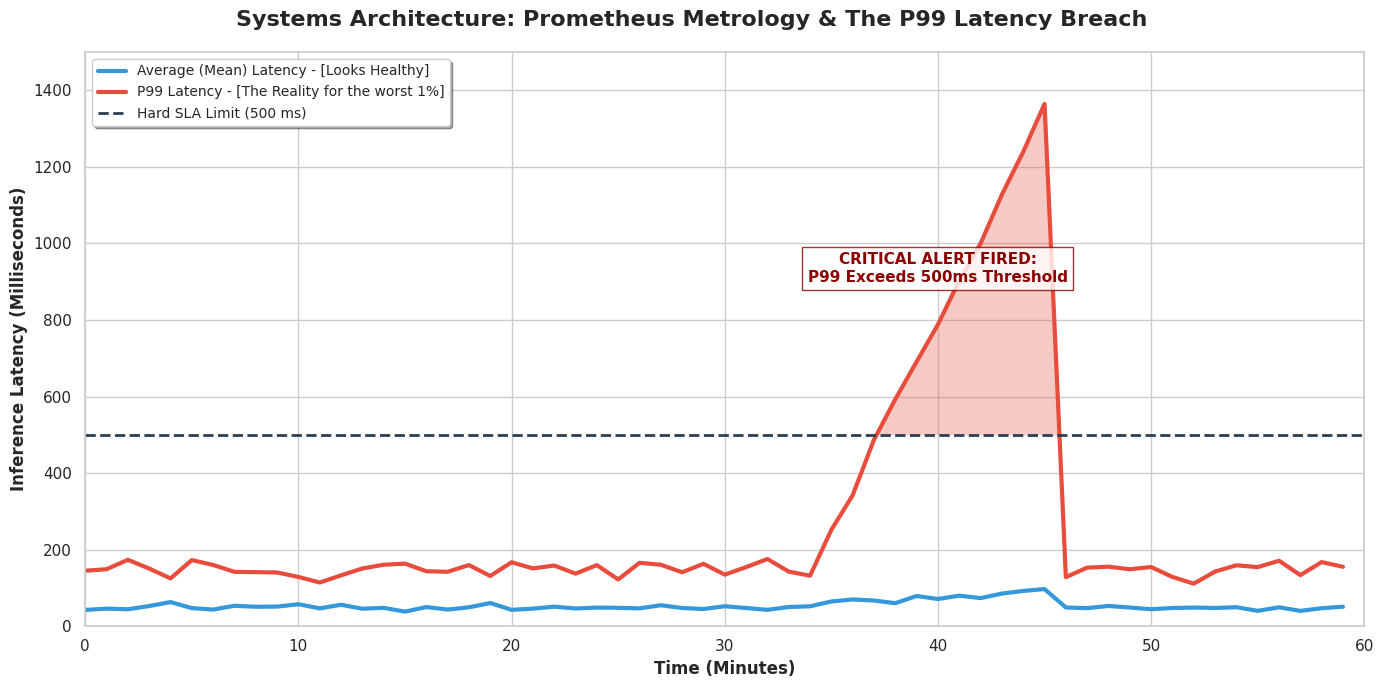

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

sns.set_theme(style="whitegrid")

# Create visual layout for Observability Physics
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Systems Architecture: Prometheus Metrology & The P99 Latency Breach", fontsize=16, fontweight='bold')

# Simulate Time Series Data (60 Minutes)
time_mins = np.arange(0, 60, 1)

# Mean latency is stable around 50ms
mean_latency = 50 + np.random.normal(0, 5, size=60)

# P99 Latency is higher, but stable around 150ms
p99_latency = 150 + np.random.normal(0, 15, size=60)

# Inject an SLA Breach (Garbage Collection / Memory Swap Spike) between min 35 and 45
spike_idx = (time_mins >= 35) & (time_mins <= 45)
mean_latency[spike_idx] += np.linspace(10, 40, sum(spike_idx)) # Mean barely notices it
p99_latency[spike_idx] += np.linspace(100, 1200, sum(spike_idx)) # P99 explodes violently

# Plot the vectors
ax.plot(time_mins, mean_latency, color='#3498db', linewidth=3, label='Average (Mean) Latency - [Looks Healthy]')
ax.plot(time_mins, p99_latency, color='#e74c3c', linewidth=3, label='P99 Latency - [The Reality for the worst 1%]')

# The strict corporate SLA boundary
SLA_LIMIT = 500
ax.axhline(SLA_LIMIT, color='#2c3e50', linestyle='--', linewidth=2, label='Hard SLA Limit (500 ms)')

# Highlight the Breach Zone
ax.fill_between(time_mins, p99_latency, SLA_LIMIT, where=(p99_latency > SLA_LIMIT), facecolor='#e74c3c', alpha=0.3, interpolate=True)
ax.text(40, 900, "CRITICAL ALERT FIRED:\nP99 Exceeds 500ms Threshold", ha='center', color='darkred', fontweight='bold', fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='darkred'))

# Graph styling
ax.set_xlabel("Time (Minutes)", fontsize=12, fontweight='bold')
ax.set_ylabel("Inference Latency (Milliseconds)", fontsize=12, fontweight='bold')
ax.set_xlim(0, 60)
ax.set_ylim(0, 1500)
ax.legend(loc="upper left", frameon=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.show()

*(Insight: If you only measure the blue line `Average Latency`, your dashboard is completely green while your most active users are experiencing massive 1.3-second load times. The red line `P99 Latency`, calculated via Prometheus Histograms, mathematically exposes the invisible friction in your GPU memory allocation.)*

## Real-World Use Case or Analogy:

Think of Prometheus Observability (The Pull Model) vs. Log Streaming (The Push Model) like **An Air Traffic Control Radar vs. A Call Center**:

* **Text Logging (The Call Center / Push Model):** You manage an airport. To know where airplanes are, you give every pilot a radio and say, *"Call me constantly and tell me your coordinates."* At 2:00 AM, it works perfectly. At 5:00 PM, 10,000 pilots all try to call the control tower at the exact same microsecond. The radio frequency jams, the tower's speakers explode, and the entire tracking system crashes purely from the effort of receiving the messages. This is what happens when thousands of distributed containers try to stream unstructured text logs to a central database during a system spike.
* **Prometheus (The Radar Sweep / Pull Model):** You install a sweeping radar tower. The pilots do not call you. They just keep flying. The radar mathematically sweeps the sky in a strict interval (e.g., exactly every 5 seconds). It bounces a signal off every plane and registers its coordinates on a green screen. If 1 plane is in the sky, the radar sweep takes 1 megabyte of memory. If 10,000 planes are in the sky, the radar sweep *still* takes exactly 1 megabyte of memory to update the screen.

By utilizing the Pull Model, Prometheus mathematically decouples the volume of user traffic from the cost of monitoring the system, allowing MLOps teams to track hundreds of millions of daily model inferences with zero system degradation.